# Daytime Hypotesis for fft


In [1]:
import pandas as pd 
import os
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import json
import mne
import numpy as np
from tqdm import tqdm
import re
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from multiprocessing import Pool
import warnings

warnings.filterwarnings("ignore")

os.chdir('../../..')

# Load data

In [2]:
loaded = np.load('./Generated/Spectrums/psds_array_fft.npz')

excluded_combinations = {
    (22, None),
    (32, 2),
    (29, 2),
    (28, 2),
    (27, None),
    (24, 2),
    (14, 2),
    (6, None),
    (34, None)
}

results_arr = []
i = 0
while f'power_{i}' in loaded:
    power = loaded[f'power_{i}']
    s_id = int(loaded[f'subject_id_{i}'])
    t_id = int(loaded[f'trial_id_{i}'])
    gender = str(loaded[f'gender_{i}'])
    handiness = str(loaded[f'handiness_{i}'])
    age = int(loaded[f'age_{i}'])
    
    exclude = False
    if (s_id, t_id) in excluded_combinations:
        exclude = True
    elif (s_id, None) in excluded_combinations:
        exclude = True
    
    if not exclude:
        results_arr.append([power, s_id, t_id, gender, handiness, age])
    
    i += 1

psd, s_id, t_id, gender, handiness, age = results_arr[0] if results_arr else [None]*6
if results_arr:
    print(f"psd shape: {psd.shape}")
print(f"Original length: {i}")
print(f"Filtered length: {len(results_arr)}")


psd shape: (63, 381)
Original length: 60
Filtered length: 55


# Processing of all records

In [3]:
psds_array = [item[0] for item in results_arr]
psds_array = np.array(psds_array)
psds_array = psds_array.reshape((psds_array.shape[0], -1))

metadata = [item[1:] for item in results_arr]

psds_array.shape

(55, 24003)

In [7]:
# After loading the npz file
loaded = np.load('./Generated/Spectrums/psds_array_fft.npz')

# Check the shape of the first power array
first_power = loaded['power_0']
print(f"Shape of first power array: {first_power.shape}")
print(f"Number of channels: {first_power.shape[0]}")
print(f"Number of frequency bins: {first_power.shape[1]}")

Shape of first power array: (63, 381)
Number of channels: 63
Number of frequency bins: 381


In [4]:
file_path = r'./Supplementary/Experiment_Metadata.xlsx'
meta = pd.read_excel(file_path, header=1).rename(columns={
    'Subject ID'          : 'Subject_id',
    'Время начала записи' : 'Time',
})

meta['Subject_id'] = (
    meta['Subject_id']
    .astype(str)
    .str.extract(r'(\d+)', expand=False)
    .astype('float')
)
meta = meta[meta['Subject_id'].notna()].copy()
meta['Subject_id'] = meta['Subject_id'].astype(int)

s  = meta['Time'].astype(str).str.strip()                    
n  = pd.to_numeric(s, errors='coerce')                        
dt_str = pd.to_datetime(s, errors='coerce', infer_datetime_format=True)
dt_num = pd.to_datetime(n, errors='coerce', origin='1899-12-30', unit='D')
dt = dt_str.fillna(dt_num)                                   

meta['Hour'] = dt.dt.hour
meta['Time'] = dt.dt.strftime('%H:%M')

meta_idx = (meta[['Subject_id', 'Hour', 'Time']]
            .dropna(subset=['Hour'])                         
            .drop_duplicates('Subject_id', keep='last'))

m = np.array(metadata, dtype=object)
df_out = pd.DataFrame({'Subject_ID': m[:,0].astype(int), 'Trial_ID': m[:,1].astype(int)})
df_out = df_out.merge(meta_idx, left_on='Subject_ID', right_on='Subject_id', how='left').drop(columns=['Subject_id'])

df_out['Condition'] = pd.cut(
    df_out['Hour'],
    bins=[-0.1, 10, 18, 24],
    labels=['Other', 'Day', 'Evening'],
    right=False,
    include_lowest=True
).astype(object).fillna('Other')

df_out = df_out[['Subject_ID', 'Trial_ID', 'Time', 'Condition']]

print(df_out['Condition'].value_counts(dropna=False))
df_out

Condition
Evening    31
Day        24
Name: count, dtype: int64


,Subject_ID,Trial_ID,Time,Condition
0,15,1,16:00,Day
1,15,2,16:00,Day
2,8,2,19:00,Evening
3,8,1,19:00,Evening
4,2,2,20:00,Evening
5,2,1,20:00,Evening
6,33,1,18:00,Evening
7,33,2,18:00,Evening
8,5,2,19:00,Evening
9,5,1,19:00,Evening


In [5]:
def map_cond(c):
    if pd.isna(c): return None
    if c == 'Day': return 'Day'
    if c == 'Evening': return 'Night'
    if c == 'Night': return 'Night'
    return None  

mapped = df_out['Condition'].apply(map_cond)

row_choice = pd.Series(mapped).where(pd.Series(mapped).notna())
mode_global = pd.Series([x for x in row_choice if pd.notna(x)]).mode().iloc[0] if pd.Series(row_choice).notna().any() else 'Day'

subj_choice = (df_out
    .assign(_choice=row_choice)
    .sort_values(['Subject_ID','Trial_ID'])
    .groupby('Subject_ID', as_index=False)['_choice']
    .agg(lambda s: next((x for x in s if pd.notna(x)), mode_global))
    .rename(columns={'_choice':'Cond_final'})
)
subj2cond = dict(zip(subj_choice['Subject_ID'], subj_choice['Cond_final']))
df_out['Cond_final'] = df_out['Subject_ID'].map(subj2cond)

print('Counts by subject condition:', pd.Series(subj2cond).value_counts().to_dict())
print(df_out['Cond_final'].value_counts(dropna=False))

first_psd = results_arr[0][0]
n_channels, n_freqs = first_psd.shape

day_vectors   = {ch: [] for ch in range(n_channels)}
night_vectors = {ch: [] for ch in range(n_channels)}
placed = {'Day': 0, 'Night': 0}

for psd, s_id, t_id, gender, handiness, age in results_arr:
    cond = subj2cond.get(int(s_id), mode_global)
    if cond == 'Day':
        for ch in range(n_channels):
            day_vectors[ch].append(psd[ch, :].astype(float))
        placed['Day'] += 1
    else:
        for ch in range(n_channels):
            night_vectors[ch].append(psd[ch, :].astype(float))
        placed['Night'] += 1

print('Placed trials:', placed)

day_matrices   = {ch: (np.vstack(v) if v else np.empty((0, n_freqs))) for ch, v in day_vectors.items()}
night_matrices = {ch: (np.vstack(v) if v else np.empty((0, n_freqs))) for ch, v in night_vectors.items()}

for ch in range(min(5, n_channels)):
    print(f'ch {ch}: day_matrix={day_matrices[ch].shape}, night_matrix={night_matrices[ch].shape}')

Counts by subject condition: {'Night': 16, 'Day': 14}
Cond_final
Night    31
Day      24
Name: count, dtype: int64
Placed trials: {'Day': 24, 'Night': 31}
ch 0: day_matrix=(24, 381), night_matrix=(31, 381)
ch 1: day_matrix=(24, 381), night_matrix=(31, 381)
ch 2: day_matrix=(24, 381), night_matrix=(31, 381)
ch 3: day_matrix=(24, 381), night_matrix=(31, 381)
ch 4: day_matrix=(24, 381), night_matrix=(31, 381)


# Statistical analysis

In [11]:
from scipy import stats
from statsmodels.stats.power import TTestIndPower

n_freqs = day_matrices[0].shape[1]


freqs = np.linspace(0, 40, n_freqs)

power_calc = TTestIndPower()
alpha = 0.05

def effect_size_d(x, y):
    nx, ny = len(x), len(y)
    sp = np.sqrt(((nx - 1) * np.var(x, ddof=1) + (ny - 1) * np.var(y, ddof=1)) / (nx + ny - 2))
    return (np.mean(x) - np.mean(y)) / sp

rows = []
for ch, D in day_matrices.items():
    N = night_matrices.get(ch, None)
    n_freqs = D.shape[1]
    for fi in range(n_freqs):
        x = D[:, fi]
        y = N[:, fi]
        t, p = stats.ttest_ind(x, y, equal_var=False, nan_policy='omit')
        d = effect_size_d(x, y)
        n1, n2 = len(x), len(y)
        ratio = n2 / n1 
        power = power_calc.solve_power(effect_size=np.abs(d), nobs1=n1, ratio=ratio,
                                           alpha=alpha, alternative='two-sided')
        i = True
        
        rows.append({
            "channel": ch,
            "freq_hz": float(freqs[fi]),
            "n_day": len(x),
            "n_night": len(y),
            "t_stat": float(t),
            "p_value": float(p),
            "power": float(power),
            "Hyp": bool(i) if power > p else not i
        })

welch_df = pd.DataFrame(rows).sort_values(["p_value", "channel", "freq_hz"])
print(welch_df.head(15))

       channel    freq_hz  n_day  n_night    t_stat   p_value     power   Hyp
10404       27  12.315789     24       31 -3.572157  0.000771  0.916575  True
10405       27  12.421053     24       31 -3.489838  0.001016  0.896752  True
10409       27  12.842105     24       31 -3.431077  0.001194  0.890837  True
10408       27  12.736842     24       31 -3.262394  0.001937  0.869819  True
10406       27  12.526316     24       31 -3.225134  0.002201  0.848624  True
10412       27  13.157895     24       31 -3.169417  0.002585  0.835960  True
10399       27  11.789474     24       31 -3.137406  0.002797  0.836506  True
13931       36  22.631579     24       31  3.245070  0.002969  0.938020  True
10413       27  13.263158     24       31 -3.102611  0.003124  0.820768  True
10420       27  14.000000     24       31 -3.094198  0.003240  0.813006  True
10423       27  14.315789     24       31 -3.063524  0.003435  0.830156  True
14076       36  37.894737     24       31  3.151287  0.003795  0

In [12]:
bands = {
    'Delta': (1, 4),
    'Tetta': (4, 7),
    'Alpha': (7, 13),
    'Beta': (13, 30)
}

band_rows = []

band_idx = {b: np.where((freqs >= lo) & (freqs < hi))[0] for b,(lo,hi) in bands.items()}

for ch, D in day_matrices.items():
    N = night_matrices.get(ch, np.empty((0, len(freqs))))
    if D.size == 0 or N.size == 0:
        continue
    for b, idx in band_idx.items():
        if len(idx) == 0:
            continue
        x = np.nanmean(D[:, idx], axis=1)
        y = np.nanmean(N[:, idx], axis=1)
        t, p = stats.ttest_ind(x, y, equal_var=False, nan_policy='omit')
        d = effect_size_d(x, y)
        try:
            n1, n2 = len(x), len(y)
            ratio = n2 / n1 if n1 > 0 else 1.0
            power = power_calc.solve_power(effect_size=np.abs(d), nobs1=n1, ratio=ratio,
                                           alpha=alpha, alternative='two-sided')
        except Exception:
            power = np.nan
        i = True
        band_rows.append({
            "channel": ch,
            "band": b,
            "n_day": len(x),
            "n_night": len(y),
            "t_stat": float(t),
            "p_value": float(p),
            "power": float(power) if np.isfinite(power) else np.nan,
            "mean_day": float(np.nanmean(x)),
            "mean_night": float(np.nanmean(y)),
            "HYP": bool(i) if  p <= 0.01 else not i
        })
band_df = pd.DataFrame(band_rows).sort_values(["p_value", "power"])
print(band_df.head(15))

from pathlib import Path
outdir = Path(file_path).parent
band_df.to_csv(outdir / "band_stats_fft_all.csv", index=False)
band_df.to_excel(outdir / "band_stats_fft_all.xlsx", index=False)

     channel   band  n_day  n_night    t_stat   p_value     power  mean_day  \
234       58  Alpha     24       31 -2.815911  0.007083  0.727667  0.000097   
147       36   Beta     24       31  2.501502  0.017623  0.754786  0.000080   
243       60   Beta     24       31  2.469368  0.020475  0.773443  0.000092   
50        12  Alpha     24       31 -2.376653  0.021168  0.604645  0.000103   
233       58  Tetta     24       31 -2.347280  0.024276  0.545243  0.000116   
198       49  Alpha     24       31 -2.306057  0.025699  0.551973  0.000126   
182       45  Alpha     24       31 -2.242780  0.029617  0.534623  0.000148   
186       46  Alpha     24       31 -2.221100  0.031008  0.531438  0.000128   
39         9   Beta     24       31  2.235823  0.034280  0.690092  0.000181   
246       61  Alpha     24       31 -2.184230  0.034777  0.495042  0.000104   
49        12  Tetta     24       31 -2.132438  0.039107  0.476043  0.000095   
43        10   Beta     24       31  2.080655  0.046

In [13]:
path = "./Generated/Data/S_1/Trial_1/EEG_clean.fif"

with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=RuntimeWarning)
    raw = mne.io.read_raw_fif(path, preload=True, verbose=False)

raw.pick_types(eeg=True)
eeg = raw

NOTE: pick_types() is a legacy function. New code should use inst.pick(...).


In [14]:
import warnings, math, numpy as np, mne
import matplotlib.pyplot as plt
from pathlib import Path

path = './Generated/Data/S_1/Trial_1/EEG_clean.fif'

with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=RuntimeWarning)
    raw = mne.io.read_raw_fif(path, preload=True, verbose=False)

eeg = raw.copy().pick_types(eeg=True)
ch_names = eeg.info['ch_names']

eeg.set_montage('standard_1020', on_missing='warn', match_case=False)

NOTE: pick_types() is a legacy function. New code should use inst.pick(...).


<Raw | EEG_clean.fif, 63 x 1548000 (1548.0 s), ~744.1 MB, data loaded>

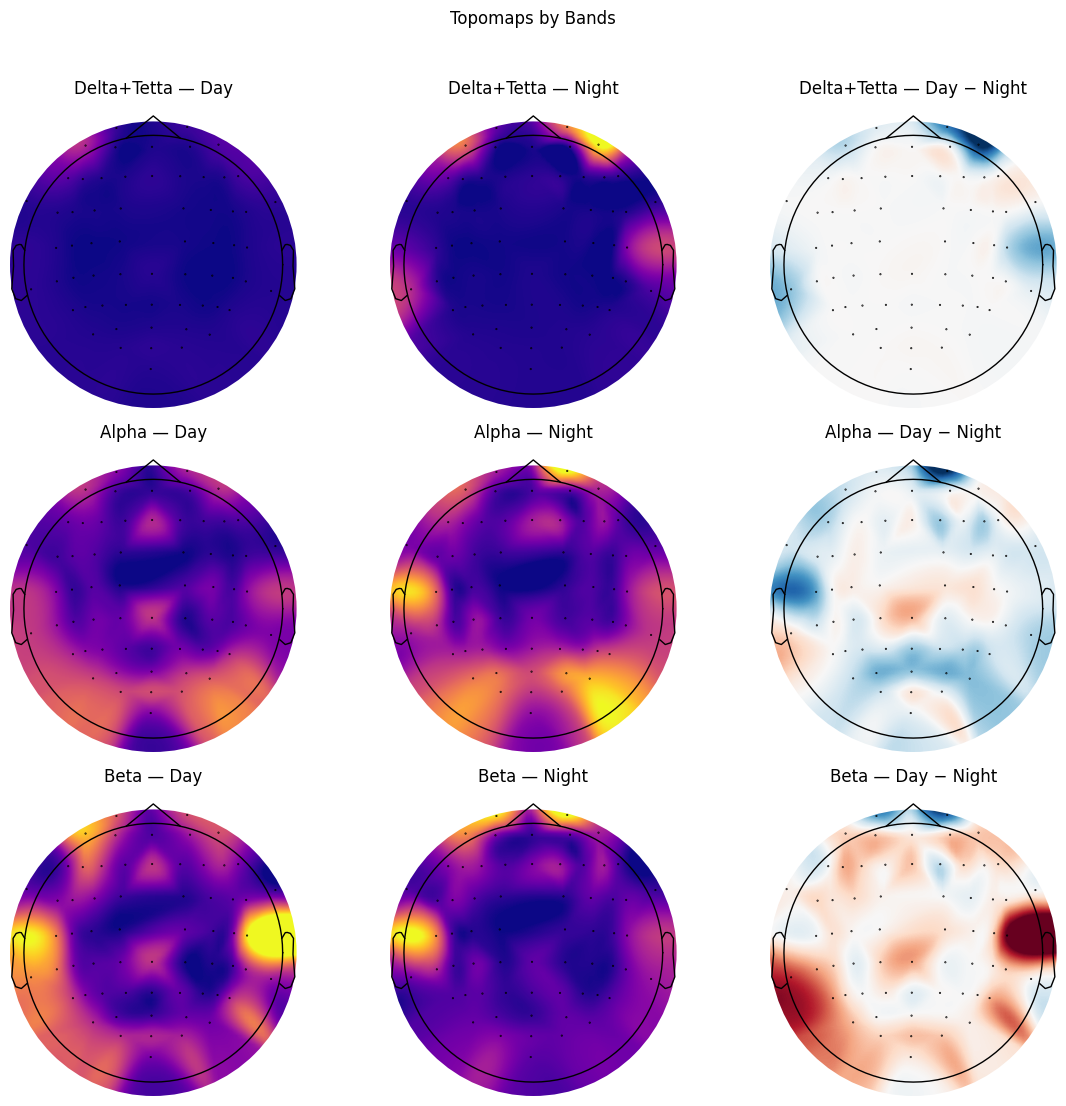

In [15]:
import numpy as np
import mne
import matplotlib.pyplot as plt
from pathlib import Path

info       = eeg.info
ch_names   = info['ch_names']
n_channels = len(ch_names)

band_limits = {
    'Delta+Tetta': (1, 7),
    'Alpha': (8, 13),
    'Beta':  (13, 30),
}

channels_to_show = [15]

if 'freqs' not in globals():
    any_ch = next((k for k,v in (day_matrices | night_matrices).items() if v.size), None)
    nF = day_matrices.get(any_ch, night_matrices.get(any_ch)).shape[1]
    freqs = np.linspace(1, 40, nF)

def band_idx(freqs, fmin, fmax):
    return np.where((freqs >= fmin) & (freqs <= fmax))[0]

def mean_over_band(mat, idx):
    if mat.size == 0 or idx.size == 0:
        return np.nan
    return float(np.nanmean(np.nanmean(mat[:, idx], axis=1)))

def build_maps(dayM, nightM, freqs, fmin, fmax, n_channels):
    idx = band_idx(freqs, fmin, fmax)
    day   = np.full(n_channels, np.nan, float)
    night = np.full(n_channels, np.nan, float)
    for ch in range(n_channels):
        D = dayM.get(ch,   np.empty((0, len(freqs))))
        N = nightM.get(ch, np.empty((0, len(freqs))))
        if D.size and D.shape[1] == len(freqs):
            day[ch]   = mean_over_band(D, idx)
        if N.size and N.shape[1] == len(freqs):
            night[ch] = mean_over_band(N, idx)
    return day, night, (day - night), idx

def vlim_pair(a, b):
    lo = np.nanmin([np.nanmin(a), np.nanmin(b)])
    hi = np.nanmax([np.nanmax(a), np.nanmax(b)])
    if not np.isfinite(lo) or not np.isfinite(hi) or lo == hi:
        return (-1.0, 1.0)
    return float(lo), float(hi)

for ch in channels_to_show:
    fig, axs = plt.subplots(len(band_limits), 3, figsize=(12, 3.6*len(band_limits)))
    axs = np.atleast_2d(axs)
    row = 0
    for band_name, (fmin_band, fmax_band) in band_limits.items():
        day_map, night_map, diff_map, idx = build_maps(day_matrices, night_matrices, freqs,
                                                       fmin_band, fmax_band, n_channels)
        if idx.size == 0:
            for col in range(3):
                axs[row, col].axis('off')
            axs[row, 1].set_title(f"{band_name} (нет точек в окне)")
            row += 1
            continue

        vmin, vmax = vlim_pair(day_map, night_map)
        vmax_abs = float(np.nanmax(np.abs(diff_map))) if np.isfinite(np.nanmax(np.abs(diff_map))) else 1.0
        vlim_diff = (-vmax_abs, vmax_abs)

        mask = np.zeros(n_channels, dtype=bool)
        if 0 <= ch < n_channels: mask[ch] = True
        mask_params = dict(markersize=10, marker='o', markerfacecolor='none',
                           markeredgewidth=2, markeredgecolor='white')

        mne.viz.plot_topomap(day_map, info, axes=axs[row, 0], show=False,
                             cmap='plasma', contours=0, vlim=(vmin, vmax))
        axs[row, 0].set_title(f"{band_name} — Day")

        mne.viz.plot_topomap(night_map, info, axes=axs[row, 1], show=False,
                             cmap='plasma', contours=0, vlim=(vmin, vmax))
        axs[row, 1].set_title(f"{band_name} — Night")

        mne.viz.plot_topomap(diff_map, info, axes=axs[row, 2], show=False,
                             cmap='RdBu_r', contours=0, vlim=vlim_diff)
        axs[row, 2].set_title(f"{band_name} — Day − Night")

        row += 1

    ch_name = ch_names[ch] if 0 <= ch < n_channels else f"#{ch}"
    plt.suptitle(f"Topomaps by Bands", y=1.02)
    plt.tight_layout()
    plt.show()

In [ ]:
import numpy as np
from scipy import stats

def band_idx(freqs, lo, hi):
    return np.where((freqs >= lo) & (freqs <= hi))[0]

def band_mean_per_channel(M, idx):
    n_channels = max(M.keys())+1
    out = np.full(n_channels, np.nan)
    for ch in range(n_channels):
        X = M.get(ch, np.empty((0, len(freqs))))
        if X.size and idx.size:
            out[ch] = np.nanmean(np.nanmean(X[:, idx], axis=1))
    return out

def band_values_for_channel(M, idx, ch):
    X = M.get(ch, np.empty((0, len(freqs))))
    return np.nanmean(X[:, idx], axis=1) if (X.size and idx.size) else np.array([])

In [ ]:
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt
import mne

def band_idx(freqs, lo, hi):
    return np.where((freqs >= lo) & (freqs <= hi))[0]

def band_values_for_channel(M, idx, ch):
    X = M.get(ch, np.empty((0, len(freqs))))
    return np.nanmean(X[:, idx], axis=1) if (X.size and idx.size) else np.array([])

def tmap_for_band(dayM, nightM, idx, n_channels):
    tvals = np.full(n_channels, np.nan)
    for ch in range(n_channels):
        x = band_values_for_channel(dayM, idx, ch)
        y = band_values_for_channel(nightM, idx, ch)
        if x.size >= 2 and y.size >= 2:
            t, _ = stats.ttest_ind(x, y, equal_var=False, nan_policy='omit')
            tvals[ch] = t
    return tvals

lo, hi = 7, 13
idx = band_idx(freqs, lo, hi)

n_channels = len(eeg.info['ch_names'])
df_mask = band_df['band'] == 'Alpha'
ff_table = band_df[df_mask]
tvals = ff_table['t_stat']

vmax = np.nanmax(np.abs(tvals))
vlim = (-vmax, vmax) if np.isfinite(vmax) and vmax > 0 else (-1, 1)

mask = np.zeros(n_channels, dtype=bool)
for ch in [15, 8, 61]:
    if 0 <= ch < n_channels:
        mask[ch] = True

fig, ax = plt.subplots(1, 1, figsize=(4.8, 4.6))
im, _ = mne.viz.plot_topomap(
    tvals, eeg.info,
    axes=ax, show=False, cmap='RdBu_r', vlim=vlim,
    contours=0, sensors=True,
    mask=mask,
    mask_params=dict(marker='o', markersize=10, markerfacecolor='none',
                     markeredgewidth=2, markeredgecolor='black')
)
ax.set_title(f'Alpha: t-stat Day vs Night (15,8,61 channels)')
plt.tight_layout()
plt.show()